In [11]:
import pandas as pd
import numpy as np
train = pd.read_csv('../data/train_eda_revised.csv')
test = pd.read_csv('../data/test_eda_revised.csv')

In [12]:
# seed 고정
import random, numpy as np, os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
print(f"Seed {SEED} 고정 완료")

Seed 42 고정 완료


In [13]:
# 합칠 대상 지정
# 합치니까 성능 저하
"""
merge_codes = ['U013', 'U005', 'U007']

# train, test 동시 적용
for df in [train, test]:
    df['business_code'] = df['business_code'].replace(
        {code: 'U_OTHER' for code in merge_codes}
    )

# 결과 확인
print(train['business_code'].value_counts())
"""

"\nmerge_codes = ['U013', 'U005', 'U007']\n\n# train, test 동시 적용\nfor df in [train, test]:\n    df['business_code'] = df['business_code'].replace(\n        {code: 'U_OTHER' for code in merge_codes}\n    )\n\n# 결과 확인\nprint(train['business_code'].value_counts())\n"

In [14]:
#정보가 중복되거나 타겟변수를 나타내 데이터 누수 가능성이 있는 피처 제거
drop_cols = ['cust_number', 'name_customer', 'clear_date', 'buisness_year', 'due_in_date', 'posting_id',
             'baseline_create_date', 'target_old', 'due_in_date', 'year_month', 'business_days_late']

In [15]:
train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True)

In [16]:
# 연체일을 나타내는 delay_days 피처 생성
# 타겟변수가 존재하기에 주석처리
"""
train['clear_date'] = pd.to_datetime(train['clear_date'])
train['due_in_date'] = pd.to_datetime(train['due_in_date'])
train['delay_days'] = (train['clear_date'] - train['due_in_date']).dt.days

test['clear_date'] = pd.to_datetime(test['clear_date'])
test['due_in_date'] = pd.to_datetime(test['due_in_date'])
test['delay_days'] = (test['clear_date'] - test['due_in_date']).dt.days

"""

"\ntrain['clear_date'] = pd.to_datetime(train['clear_date'])\ntrain['due_in_date'] = pd.to_datetime(train['due_in_date'])\ntrain['delay_days'] = (train['clear_date'] - train['due_in_date']).dt.days\n\ntest['clear_date'] = pd.to_datetime(test['clear_date'])\ntest['due_in_date'] = pd.to_datetime(test['due_in_date'])\ntest['delay_days'] = (test['clear_date'] - test['due_in_date']).dt.days\n\n"

In [17]:
#이진 분류 먼저 검증하기 위해 주석처리

"""
bins = [-float('inf'), 0, 5, 15, float('inf')]
labels = ['on_time_or_early', '1_5', '6_15', '16_plus']

# 4개의 클래스로 타깃 피처 생성(정상, 1-5일 지연, 6-15일 지연, 16이상 지연)
train['delay_class'] = pd.cut(train['delay_days'], bins=bins, labels=labels)
train['delay_class'].value_counts(dropna=False)
train['delay_class'].value_counts(normalize=True, dropna=False) * 100

test['delay_class'] = pd.cut(test['delay_days'], bins=bins, labels=labels)
test['delay_class'].value_counts(dropna=False)
test['delay_class'].value_counts(normalize=True, dropna=False) * 100
"""

"\nbins = [-float('inf'), 0, 5, 15, float('inf')]\nlabels = ['on_time_or_early', '1_5', '6_15', '16_plus']\n\n# 4개의 클래스로 타깃 피처 생성(정상, 1-5일 지연, 6-15일 지연, 16이상 지연)\ntrain['delay_class'] = pd.cut(train['delay_days'], bins=bins, labels=labels)\ntrain['delay_class'].value_counts(dropna=False)\ntrain['delay_class'].value_counts(normalize=True, dropna=False) * 100\n\ntest['delay_class'] = pd.cut(test['delay_days'], bins=bins, labels=labels)\ntest['delay_class'].value_counts(dropna=False)\ntest['delay_class'].value_counts(normalize=True, dropna=False) * 100\n"

In [18]:
train = train.dropna().copy()
test = test.dropna().copy()

In [19]:
corr_matrix = train.select_dtypes(include='number').corr(method='pearson')
corr_with_target = train.select_dtypes(include='number').corrwith(train['target']).abs()
threshold = 0.8

drop_cols = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        f1 = corr_matrix.columns[i]
        f2 = corr_matrix.columns[j]
        if abs(corr_matrix.iloc[i, j]) >= threshold:
            # target과 상관 낮은 쪽 제거
            drop = f1 if corr_with_target[f1] < corr_with_target[f2] else f2
            drop_cols.add(drop)
            print(f"제거: {drop}  (유지: {f2 if drop==f1 else f1}, corr_with_target={corr_with_target[drop]:.4f})")

train = train.drop(columns=list(drop_cols))
test  = test.drop(columns=list(drop_cols))

print(f"\n최종 피처 수: {train.shape[1]}")

제거: amount_in_usd  (유지: amount_bin, corr_with_target=0.0248)
제거: hy_spread_proxy  (유지: baseline_month, corr_with_target=0.0132)
제거: baseline_month  (유지: hy_spread_proxy_lag1, corr_with_target=0.0153)
제거: baseline_month  (유지: hy_spread_proxy_lag2, corr_with_target=0.0153)
제거: hy_spread_proxy_lag3  (유지: baseline_month, corr_with_target=0.0121)
제거: unemployment  (유지: baseline_month, corr_with_target=0.0114)
제거: fed_rate  (유지: baseline_month, corr_with_target=0.0126)
제거: dxy  (유지: baseline_month, corr_with_target=0.0107)
제거: retail_sales  (유지: baseline_month, corr_with_target=0.0124)
제거: fed_rate_chg  (유지: baseline_month, corr_with_target=0.0137)
제거: ratio_paid_invoices_late_past  (유지: cust_allowed_pay_days_late_rate_past, corr_with_target=0.5626)
제거: recent_10_late_rate  (유지: cust_allowed_pay_days_late_rate_past, corr_with_target=0.4841)
제거: recent_20_late_rate  (유지: cust_allowed_pay_days_late_rate_past, corr_with_target=0.5280)
제거: late_rate_time_decay_lambda_0_8  (유지: cust_allowed_pay_d

In [ ]:
from sklearn.preprocessing import StandardScaler

# 수치형 피처만 표준화
num_cols = train_x.select_dtypes(exclude=['object', 'category']).columns.tolist()

scaler = StandardScaler()
train_x[num_cols] = scaler.fit_transform(train_x[num_cols])
test_x[num_cols] = scaler.transform(test_x[num_cols])

print(f"표준화 완료: {len(num_cols)}개 수치형 피처")
print(f"train_x 통계:\n{train_x[num_cols].describe()}")

In [20]:
from sklearn.preprocessing import OneHotEncoder
# 타깃 피처 분리
train_y = train['target'].copy()
train_x = train.drop(columns='target', axis=1)
test_y = test['target'].copy()
test_x = test.drop(columns='target', axis=1)

#원핫 인코딩
cat_cols = train_x.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = train_x.select_dtypes(exclude=['object', 'category']).columns.tolist()
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
train_cat = ohe.fit_transform(train_x[cat_cols])
test_cat = ohe.transform(test_x[cat_cols])

train_cat_df = pd.DataFrame(
    train_cat,
    columns=ohe.get_feature_names_out(cat_cols),
    index=train_x.index
)

test_cat_df = pd.DataFrame(
    test_cat,
    columns=ohe.get_feature_names_out(cat_cols),
    index=test_x.index
)

train_x = pd.concat([train_x[num_cols], train_cat_df], axis=1)
test_x = pd.concat([test_x[num_cols], test_cat_df], axis=1)


In [21]:
#단일 모델로 로지스틱 회귀 사용
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
lr = LogisticRegression(
    max_iter=5000,
    random_state=42,
    class_weight='balanced'
)

lr.fit(train_x, train_y)
pred = lr.predict(test_x)

c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
labels = train_y.unique()
print('accuracy:', accuracy_score(test_y, pred))
print('-------------')
print('macro f1:', f1_score(test_y, pred, average='macro'))
print('-------------')

accuracy: 0.922375
-------------
macro f1: 0.7074472172771498
-------------


In [23]:
import pandas as pd
import numpy as np

# 회귀 계수 추출
coef_df = pd.DataFrame({
    'feature'    : train_x.columns,
    'coefficient': lr.coef_[0],          # lr.coef_ shape: (1, n_features)
    'odds_ratio' : np.exp(lr.coef_[0])   # 오즈비 = e^계수
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))

                             feature  coefficient  odds_ratio
cust_allowed_pay_days_late_rate_past     3.437478   31.108416
             cust_payment_terms_NAX2     2.377971   10.783001
         cust_payment_terms_grp_NAX2     2.377971   10.783001
             cust_payment_terms_NAM1    -1.654487    0.191190
         cust_payment_terms_grp_NAM1    -1.654487    0.191190
         cust_payment_terms_grp_NAAW    -1.497515    0.223685
             cust_payment_terms_NAAW    -1.497515    0.223685
         cust_payment_terms_grp_NAWU    -1.459054    0.232456
             cust_payment_terms_NAWU    -1.459054    0.232456
             cust_payment_terms_NAVR    -1.365461    0.255263
         cust_payment_terms_grp_NAVR    -1.365461    0.255263
             cust_payment_terms_NATW     1.357451    3.886274
             cust_payment_terms_NAVM     1.264075    3.539816
         cust_payment_terms_grp_NAVM     1.264075    3.539816
         cust_payment_terms_grp_NAM4    -1.146962    0.317600
        

## 스태킹 코드

In [24]:
pip install xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.


In [25]:
# 모델링의 필요한 라이브러리 임포트

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import numpy as np
import pandas as pd

In [26]:
#베이스 모델과 메타 모델 정의
base_models = {
    'lr': LogisticRegression(
        max_iter=5000, random_state=SEED, class_weight='balanced'
    ),
    'rf': RandomForestClassifier(
        n_estimators=300, random_state=SEED, class_weight='balanced', n_jobs=-1
    ),
    'xgb': xgb.XGBClassifier(
        n_estimators=300, random_state=SEED,
        seed=SEED,                  # XGBoost 전용 파라미터
        eval_metric='logloss'
    ),
    'lgbm': lgb.LGBMClassifier(
        n_estimators=300, random_state=SEED,
        seed=SEED,                  # LightGBM 전용 파라미터
        verbose=-1
    )
}


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

meta_model = LogisticRegression(
    penalty='l1', solver='saga', C=1.0,
    max_iter=3000, random_state=SEED
)

In [27]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# 메타 모델 학습용 OOF(Out-Of-Fold) 예측 확률 배열
oof_preds   = np.zeros((len(train_x), len(base_models)))   # shape: (train 샘플수, 4)
# 테스트 예측 확률 배열 (각 fold 평균 사용)
test_preds  = np.zeros((len(test_x),  len(base_models)))   # shape: (test 샘플수, 4)

X = train_x.values
y = train_y.values
X_test = test_x.values

for m_idx, (model_name, model) in enumerate(base_models.items()):
    test_fold_preds = np.zeros((len(test_x), N_SPLITS))  # fold별 test 예측 보관

    print(f"\n[{model_name}] CV 시작")
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        # LR은 스케일링 필요
        if model_name == 'lr':
            scaler = StandardScaler()
            X_tr  = scaler.fit_transform(X_tr)
            X_val = scaler.transform(X_val)
            X_te  = scaler.transform(X_test)
        else:
            X_te = X_test

        model.fit(X_tr, y_tr)

        # ── OOF 확률값 저장 (연체=1 클래스의 확률)
        oof_preds[val_idx, m_idx] = model.predict_proba(X_val)[:, 1]
        # ── test 확률값 저장 (fold별)
        test_fold_preds[:, fold]  = model.predict_proba(X_te)[:, 1]

        fold_f1 = f1_score(y_val, model.predict(X_val), average='macro')
        print(f"  Fold {fold+1} macro F1: {fold_f1:.4f}")

    # fold 평균으로 최종 test 예측 확률 결정
    test_preds[:, m_idx] = test_fold_preds.mean(axis=1)
    print(f"[{model_name}] OOF macro F1: {f1_score(y, (oof_preds[:, m_idx] > 0.5).astype(int), average='macro'):.4f}")


[lr] CV 시작
  Fold 1 macro F1: 0.6942
  Fold 2 macro F1: 0.6927
  Fold 3 macro F1: 0.6835
  Fold 4 macro F1: 0.6903
  Fold 5 macro F1: 0.6983
[lr] OOF macro F1: 0.6917

[rf] CV 시작
  Fold 1 macro F1: 0.7735
  Fold 2 macro F1: 0.7990
  Fold 3 macro F1: 0.7918
  Fold 4 macro F1: 0.8069
  Fold 5 macro F1: 0.7809
[rf] OOF macro F1: 0.7904

[xgb] CV 시작
  Fold 1 macro F1: 0.8107
  Fold 2 macro F1: 0.8043
  Fold 3 macro F1: 0.7994
  Fold 4 macro F1: 0.8131
  Fold 5 macro F1: 0.7971
[xgb] OOF macro F1: 0.8050

[lgbm] CV 시작


c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 1 macro F1: 0.8041


c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 2 macro F1: 0.8085


c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 3 macro F1: 0.8057


c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 4 macro F1: 0.8216
  Fold 5 macro F1: 0.7949
[lgbm] OOF macro F1: 0.8071


c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [29]:
# ── 메타 모델 학습: OOF 확률값(4개 열) → 실제 타깃
meta_model.fit(oof_preds, y)

# ── 최종 예측
final_pred      = meta_model.predict(test_preds)
final_pred_prob = meta_model.predict_proba(test_preds)[:, 1]

# ── 평가
binary_labels = [0, 1]
print("=" * 50)
print(f"[스태킹] accuracy : {accuracy_score(test_y, final_pred):.4f}")
print(f"[스태킹] macro F1 : {f1_score(test_y, final_pred, average='macro'):.4f}")
print("=" * 50)
print(classification_report(test_y, final_pred, labels=binary_labels))
print(confusion_matrix(test_y, final_pred, labels=binary_labels))

[스태킹] accuracy : 0.9634
[스태킹] macro F1 : 0.7661
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      7567
           1       0.82      0.42      0.55       433

    accuracy                           0.96      8000
   macro avg       0.89      0.71      0.77      8000
weighted avg       0.96      0.96      0.96      8000

[[7527   40]
 [ 253  180]]


c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\user\anaconda3\envs\env1\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [234]:
# 베이스라인(단순 LR) vs 스태킹 비교
baseline_pred = lr.predict(test_x)

results = pd.DataFrame({
    '모델': ['Baseline (단순 LR)', 'Stacking (LR+RF+XGB+LGBM)'],
    'Accuracy': [
        accuracy_score(test_y, baseline_pred),
        accuracy_score(test_y, final_pred)
    ],
    'Macro F1': [
        f1_score(test_y, baseline_pred, average='macro'),
        f1_score(test_y, final_pred, average='macro')
    ]
})

print(results.to_string(index=False))

                       모델  Accuracy  Macro F1
         Baseline (단순 LR)  0.922375  0.707447
Stacking (LR+RF+XGB+LGBM)  0.963375  0.766105


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'   # 없으면 'DejaVu Sans'로 변경
plt.rcParams['axes.unicode_minus'] = False

feature_names = train_x.columns.tolist()

# ── 1. RF: feature_importances_ (Gini 기반, 트리 계열 표준)
rf_final = base_models['rf']   # CV 마지막 fold 학습된 모델 (전체 재학습 권장)
rf_importance = pd.Series(rf_final.feature_importances_, index=feature_names).sort_values(ascending=False)

# ── 2. XGBoost: feature_importances_ (gain 기반)
xgb_final = base_models['xgb']
xgb_importance = pd.Series(xgb_final.feature_importances_, index=feature_names).sort_values(ascending=False)

# ── 3. LightGBM: feature_importances_ (split 기반)
lgbm_final = base_models['lgbm']
lgbm_importance = pd.Series(lgbm_final.feature_importances_, index=feature_names).sort_values(ascending=False)

# ── 4. LR: 계수 절대값 
from sklearn.preprocessing import StandardScaler
lr_final = base_models['lr']
lr_importance = pd.Series(np.abs(lr_final.coef_[0]), index=feature_names).sort_values(ascending=False)

print("각 모델 상위 5개 피처")
print("─" * 50)
for name, imp in [("RF", rf_importance), ("XGB", xgb_importance), ("LGBM", lgbm_importance), ("LR", lr_importance)]:
    print(f"[{name}] {list(imp.head(5).index)}")

각 모델 상위 5개 피처
──────────────────────────────────────────────────
[RF] ['cust_allowed_pay_days_late_rate_past', 'sum_outstanding_amount_past', 'recent_3_late_rate', 'baseline_day', 'avg_days_late_paid_late_past']
[XGB] ['cust_allowed_pay_days_late_rate_past', 'is_new_customer', 'cust_payment_terms_NAH4', 'cust_payment_terms_NAX2', 'cust_payment_terms_NAG2']
[LGBM] ['sum_outstanding_amount_past', 'baseline_day', 'avg_days_late_paid_late_past', 'cust_allowed_pay_days_late_rate_past', 'baseline_dayofweek']
[LR] ['cust_allowed_pay_days_late_rate_past', 'cust_payment_terms_NAX2', 'cust_payment_terms_grp_NAX2', 'is_new_customer', 'amount_bin']


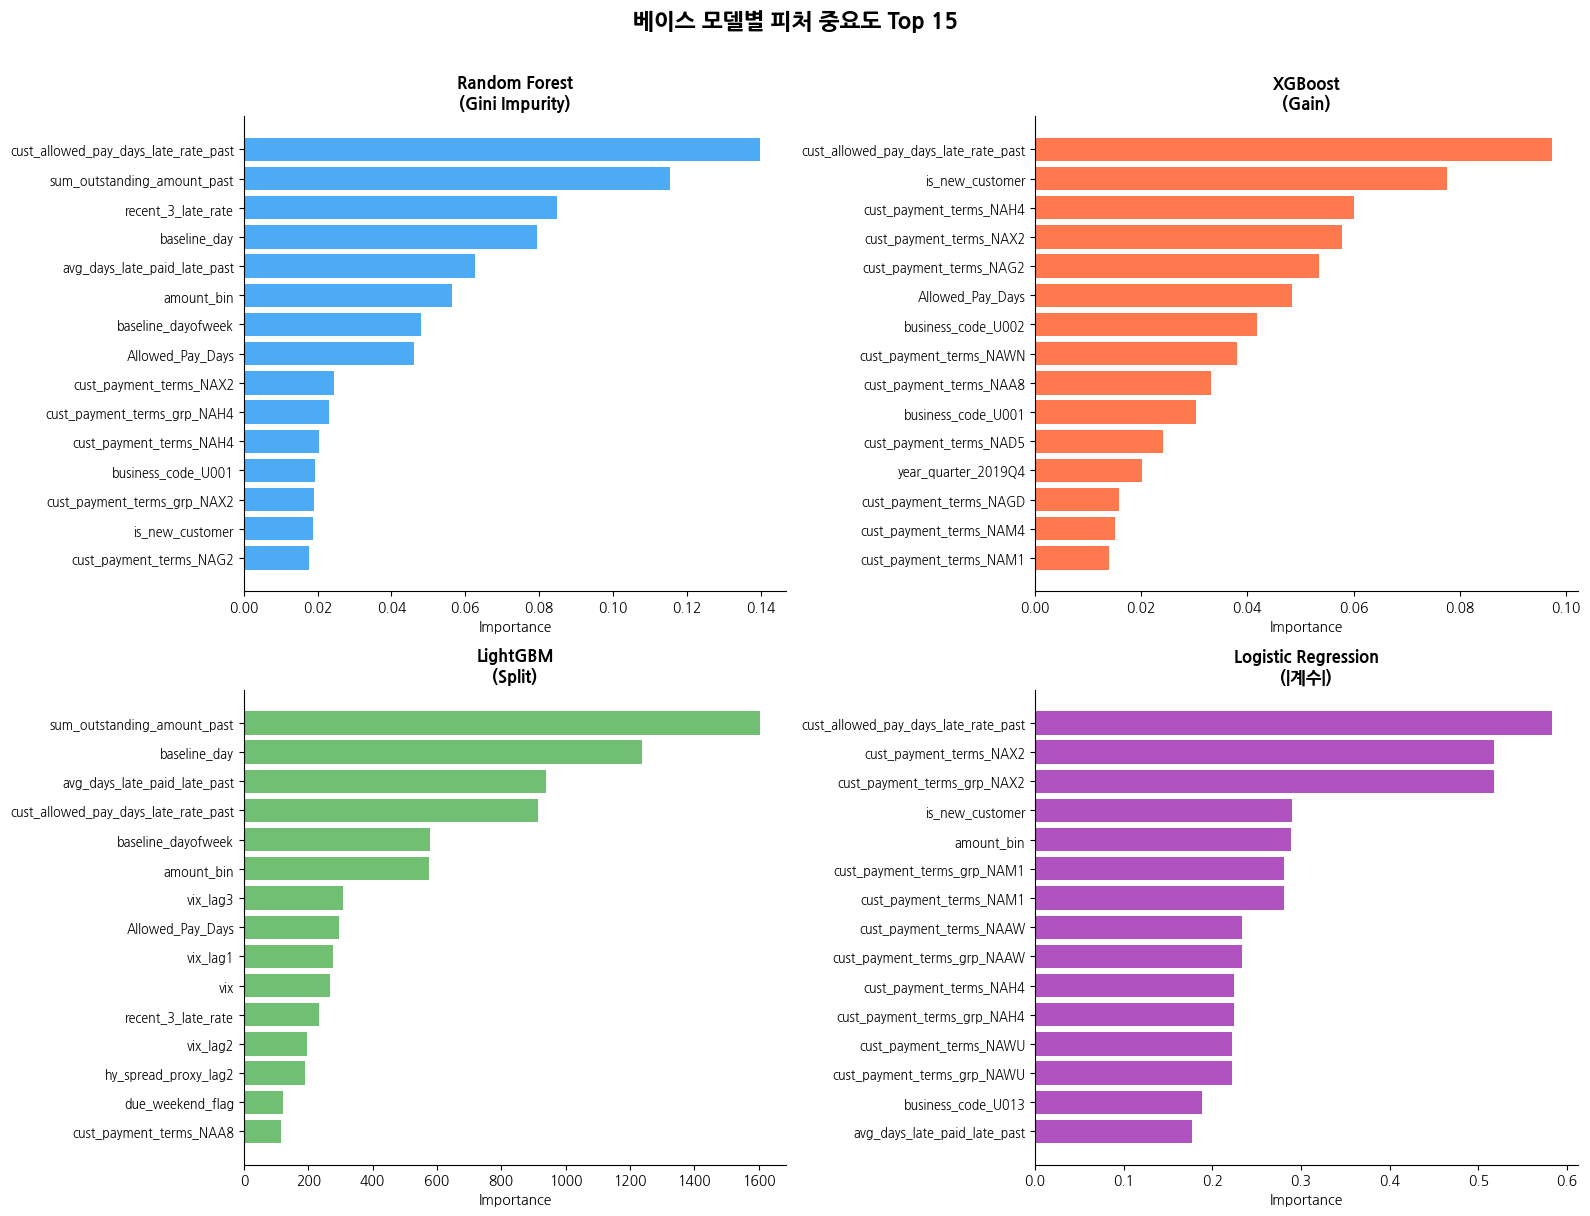

저장: feature_importance_by_model.png


In [241]:
TOP_N = 15

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('베이스 모델별 피처 중요도 Top 15', fontsize=16, fontweight='bold', y=1.01)

plot_data = [
    ("Random Forest\n(Gini Impurity)", rf_importance, "#2196F3"),
    ("XGBoost\n(Gain)", xgb_importance, "#FF5722"),
    ("LightGBM\n(Split)", lgbm_importance, "#4CAF50"),
    ("Logistic Regression\n(|계수|)", lr_importance, "#9C27B0"),
]

for ax, (title, importance, color) in zip(axes.flatten(), plot_data):
    top = importance.head(TOP_N)
    ax.barh(range(TOP_N), top.values[::-1], color=color, alpha=0.8)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top.index[::-1], fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Importance")
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance_by_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: feature_importance_by_model.png")

메타 모델 계수 (양수=연체 기여, 음수=정상 기여)
  LR (로지스틱 회귀)              +2.9309  ▲ 연체 기여
  RF (랜덤 포레스트)              +3.0384  ▲ 연체 기여
  XGB (XGBoost)             +0.0707  ▲ 연체 기여
  LGBM (LightGBM)           +1.7850  ▲ 연체 기여


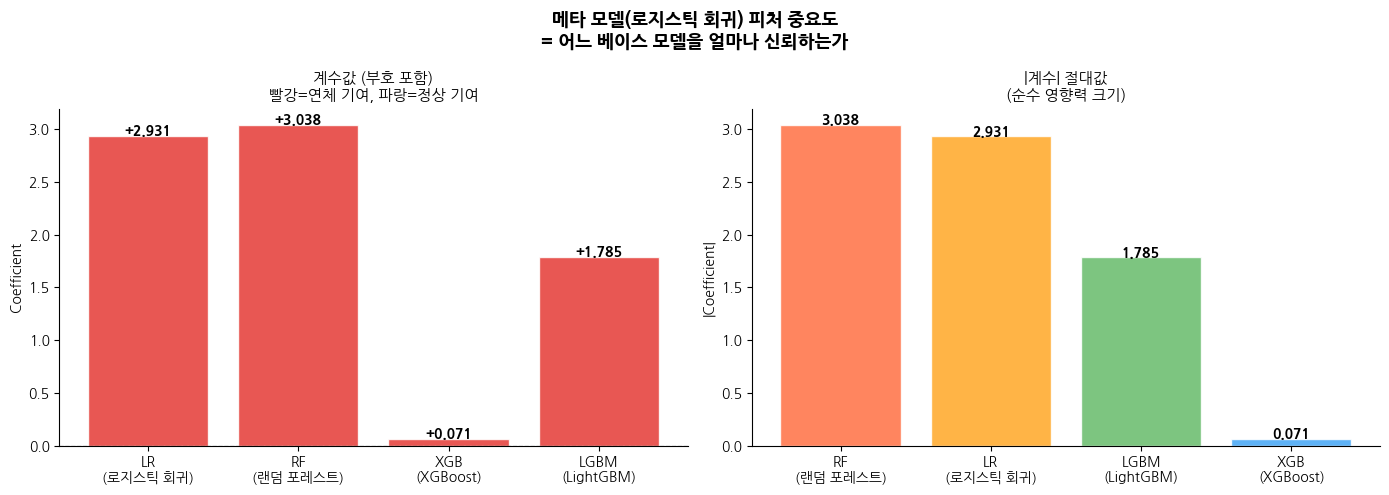

저장: meta_model_feature_importance.png


In [237]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 메타 모델 계수 추출
# meta_model의 입력: [LR_prob, RF_prob, XGB_prob, LGBM_prob]
meta_feature_names = ['LR\n(로지스틱 회귀)', 'RF\n(랜덤 포레스트)', 'XGB\n(XGBoost)', 'LGBM\n(LightGBM)']
meta_coef = meta_model.coef_[0]  # shape: (4,)

meta_importance = pd.Series(meta_coef, index=meta_feature_names)
meta_importance_sorted = meta_importance.abs().sort_values(ascending=False)

print("=" * 45)
print("메타 모델 계수 (양수=연체 기여, 음수=정상 기여)")
print("=" * 45)
for name, coef in zip(meta_feature_names, meta_coef):
    direction = "▲ 연체 기여" if coef > 0 else "▼ 정상 기여"
    print(f"  {name.replace(chr(10), ' '):<25} {coef:+.4f}  {direction}")

# ── 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('메타 모델(로지스틱 회귀) 피처 중요도\n= 어느 베이스 모델을 얼마나 신뢰하는가', 
             fontsize=13, fontweight='bold')

# 왼쪽: 원래 계수값 (부호 포함 → 방향성 파악)
colors = ['#E53935' if c > 0 else '#1E88E5' for c in meta_coef]
axes[0].bar(meta_feature_names, meta_coef, color=colors, alpha=0.85, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('계수값 (부호 포함)\n빨강=연체 기여, 파랑=정상 기여', fontsize=11)
axes[0].set_ylabel('Coefficient')
axes[0].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(meta_coef):
    axes[0].text(i, v + 0.01 * np.sign(v), f'{v:+.3f}', ha='center', fontsize=10, fontweight='bold')

# 오른쪽: 절대값 (순수 영향력 크기)
imp_sorted_idx = np.argsort(np.abs(meta_coef))[::-1]
sorted_names = [meta_feature_names[i] for i in imp_sorted_idx]
sorted_abs   = np.abs(meta_coef)[imp_sorted_idx]
bar_colors   = ['#FF7043', '#FFA726', '#66BB6A', '#42A5F5']

axes[1].bar(sorted_names, sorted_abs, color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_title('|계수| 절대값\n(순수 영향력 크기)', fontsize=11)
axes[1].set_ylabel('|Coefficient|')
axes[1].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(sorted_abs):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('meta_model_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: meta_model_feature_importance.png")

In [238]:
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, f1_score

# 최종 예측 확률 (앞서 구한 final_pred_prob 사용)
thresholds = np.arange(0.1, 0.9, 0.01)

results = []
for t in thresholds:
    pred_t = (final_pred_prob >= t).astype(int)
    results.append({
        'threshold' : round(t, 2),
        'accuracy'  : accuracy_score(test_y, pred_t),
        'macro_f1'  : f1_score(test_y, pred_t, average='macro'),
        'f1_class1' : f1_score(test_y, pred_t, pos_label=1, average='binary')
        
    })

threshold_df = pd.DataFrame(results)

# 목적에 따라 기준 선택
best_macro_f1  = threshold_df.loc[threshold_df['macro_f1'].idxmax()]
best_f1_class1 = threshold_df.loc[threshold_df['f1_class1'].idxmax()]

print("[ macro F1 최대 임계치 ]")
print(best_macro_f1.to_string())
print("\n[ 연체(class=1) F1 최대 임계치 ]")
print(best_f1_class1.to_string())

[ macro F1 최대 임계치 ]
threshold    0.340000
accuracy     0.962875
macro_f1     0.777848
f1_class1    0.575107

[ 연체(class=1) F1 최대 임계치 ]
threshold    0.340000
accuracy     0.962875
macro_f1     0.777848
f1_class1    0.575107


In [239]:
meta_model.coef_

array([[2.93086565, 3.03836851, 0.07065973, 1.78501469]])

In [255]:
import numpy as np

PDO     = 20
ODDS_0  = 20    # PD≈4.76% 기업이 600점 기준
SCORE_0 = 600

def prob_to_score_v1(prob):
    """본인 공식 (오즈=1일 때 600점 → 문제)"""
    prob = np.clip(prob, 1e-6, 1-1e-6)
    odds = (1 - prob) / prob
    return np.round(SCORE_0 + PDO * np.log2(odds)).astype(int)

def prob_to_score_v2(prob):
    """수정 공식 (오즈=20일 때 600점 → 올바름)"""
    prob = np.clip(prob, 1e-6, 1-1e-6)
    odds = (1 - prob) / prob
    return np.round(SCORE_0 + PDO * np.log2(odds / ODDS_0)).astype(int)

# 검증
for pd_val in [0.02, 0.05, 0.10, 0.30, 0.50]:
    print(f"PD={pd_val:.0%}  v1={prob_to_score_v1(pd_val):4d}  v2={prob_to_score_v2(pd_val):4d}")

PD=2%  v1= 712  v2= 626
PD=5%  v1= 685  v2= 599
PD=10%  v1= 663  v2= 577
PD=30%  v1= 624  v2= 538
PD=50%  v1= 600  v2= 514
